# **Task 1 Problem Identification**

**Identify what type of computer vision problem the dataset represents**

This dataset represent 'Image Classification' problem.

Here the goal is to assign one one label to each image from the following four classes:


1.   normal
2.   scratch
3. dent
4. stain

Also the dataset clearly indicate. 'Build a CNN model to classify product images into one of four classes.'

In image classifiation:

Each image belongs to one

*   Each image belongs to one category.
*   The model predicts a single class label  




# **Task 2 Dataset Exploration**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
labels = pd.read_csv('/content/labels.csv')

In [ ]:
# Number of classes
classes = labels['class'].unique()

print('Classes in dataset: ' + str(classes))
print(f'Number of classes: {len(classes)}')


Classes in dataset: ['normal' 'scratch' 'dent' 'stain']
Number of classes: 4


In [ ]:
# Number of images per class
class_count = labels['class'].value_counts()

print('Number of images per class:')
print(class_count)

Number of images per class:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


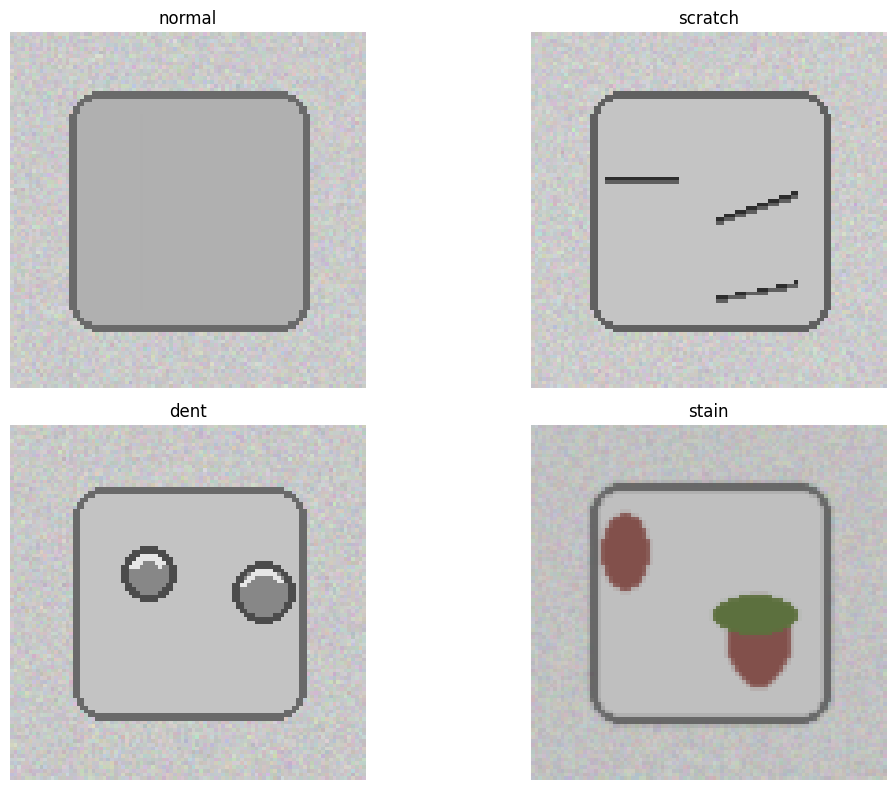

In [ ]:
# Sample images from each class

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to images folder
image_paths = "/content/images"

# Class names
classes = ['normal', 'scratch', 'dent', 'stain']

# Plot figure
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    # Path of class folder
    class_folder = os.path.join(image_paths, class_name)

    # List all images in folder
    image_list = os.listdir(class_folder)

    # Select random image
    image_name = random.choice(image_list)

    # Full image path
    image_path = os.path.join(class_folder, image_name)

    # Open image
    img = Image.open(image_path)

    # Display image
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Image dimensions
print("Image dimensions:")

for class_name in classes:
    class_folder = os.path.join(image_paths, class_name)
    image_list = os.listdir(class_folder)
    if image_list:
        image_name = random.choice(image_list)
        image_path = os.path.join(class_folder, image_name)
        img = Image.open(image_path)
        width, height = img.size
        print(f"{class_name}: {width}x{height}")
    else:
        print(f"No images found for class: {class_name}")

Image dimensions:
normal: 96x96
scratch: 96x96
dent: 96x96
stain: 96x96


In [ ]:
# Any imbalance in the dataset

print("Any imbalance in the dataset:")

if class_count.nunique() == 1:
    print("No imbalance in the dataset")
else:
    print("Imbalance in the dataset")

Any imbalance in the dataset:
No imbalance in the dataset


# **Task 3 Image Preprocessing**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Load and preprocess images

images = []
labels_list = []

IMG_SIZE = 125

for label, class_name in enumerate(classes):
  class_folder = os.path.join(image_paths, class_name)
  image_list = os.listdir(class_folder)
  for image_name in image_list:
    image_path = os.path.join(class_folder, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    # Normalize pixel values
    img = img / 255.0

    images.append(img)
    labels_list.append(label)



In [ ]:
# Image array

X = np.array(images)
y = np.array(labels_list)

print('Image array shape: ' + str(X.shape))
print('Label array shape: ' + str(y.shape))

Image array shape: (480, 125, 125, 3)
Label array shape: (480,)


In [ ]:
# Splitting into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set size: ' + str(X_train.shape[0]))
print('Testing set size: ' + str(X_test.shape[0]))

Training set size: 384
Testing set size: 96


In [ ]:
# Applying augmentation, if needed

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range = 0.2)


datagen.fit(X_train)
print("Image preprocessing completed successfully!")


Image preprocessing completed successfully!


# **Task 4 CNN Model Creation**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout)

# Build CNN model

model = Sequential()

# Convolution Layer & Activation Function

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(MaxPooling2D((2, 2)))

# Pooling Layer

model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Pooling Layer

model.add(Conv2D(64, (3, 3), activation='relu'))

# Flatten Layer

model.add(Flatten())

# Dense Layer

model.add(Dense(64, activation='relu'))

# Output Layer

model.add(Dense(len(classes), activation='softmax'))

# Compile Model

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 123, 123, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,230,980 (12.33 MB)

 Trainable params: 3,230,980 (12.33 MB)

 Non-trainable params: 0 (0.00 B)

# **Task 5 Model Training and Evaluation**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

In [ ]:
# Train CNN Model

history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    epochs=10,
                    validation_data=(X_test, y_test))

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 405ms/step - accuracy: 0.2422 - loss: 378.5635 - val_accuracy: 0.2500 - val_loss: 3.9304
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 0.3776 - loss: 1.4534 - val_accuracy: 0.4583 - val_loss: 1.0836
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 344ms/step - accuracy: 0.4635 - loss: 1.0867 - val_accuracy: 0.5938 - val_loss: 1.0562
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 398ms/step - accuracy: 0.5286 - loss: 1.0708 - val_accuracy: 0.5729 - val_loss: 1.0403
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 297ms/step - accuracy: 0.5365 - loss: 1.0504 - val_accuracy: 0.5521 - val_loss: 1.0434
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 294ms/step - accuracy: 0.5417 - loss: 1.0325 - val_accuracy: 0.5833 - val_loss: 1.0157
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 392ms/step - accuracy: 0.5443 - loss: 1.0131 - val_accuracy: 0.5729 - val_loss: 1.0063
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 382ms/step - accuracy: 0.5495 - loss: 1.0021 - val_accuracy: 

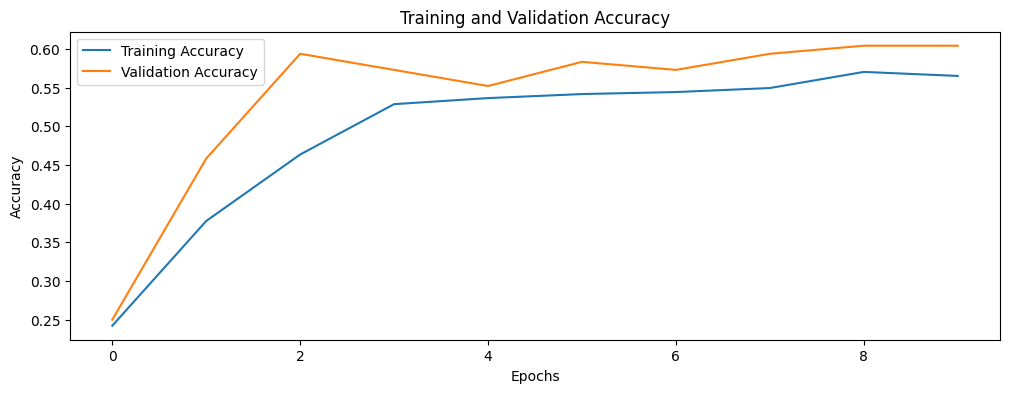

In [ ]:
# Training accuracy/loss

# Accuracy Plot

plt.figure(figsize=(12, 4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


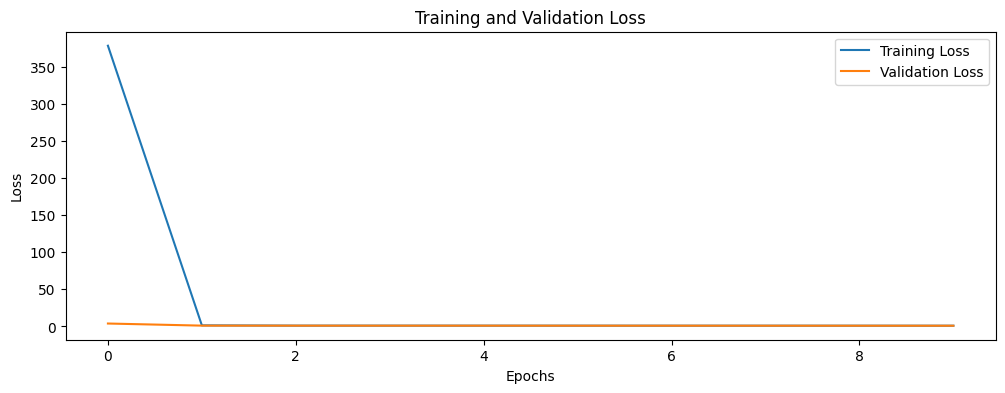

In [ ]:
# Loss Plot

plt.figure(figsize=(12, 4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Testing performance

test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)
print('Test loss:', test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6042 - loss: 0.9635
Test accuracy: 0.6041666865348816
Test loss: 0.9635009765625


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


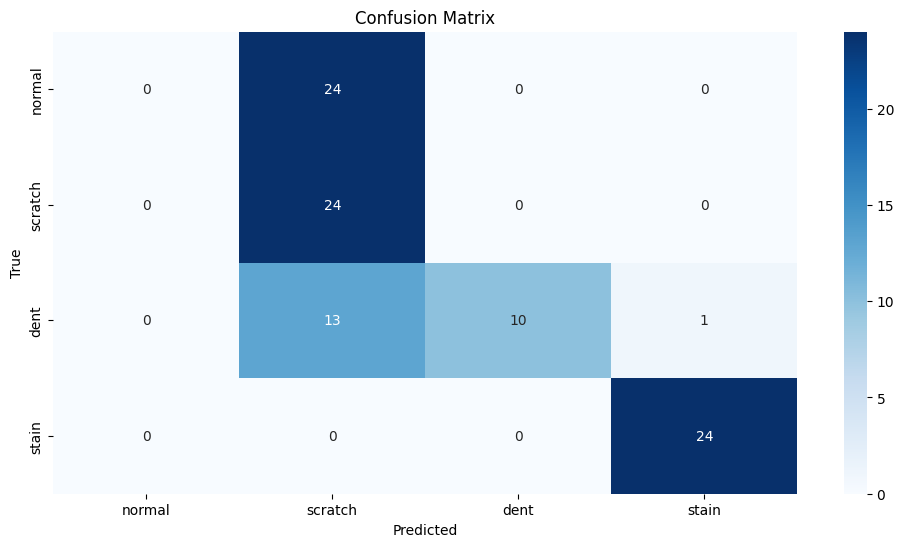

In [ ]:
# Confusion matrix

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(12, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

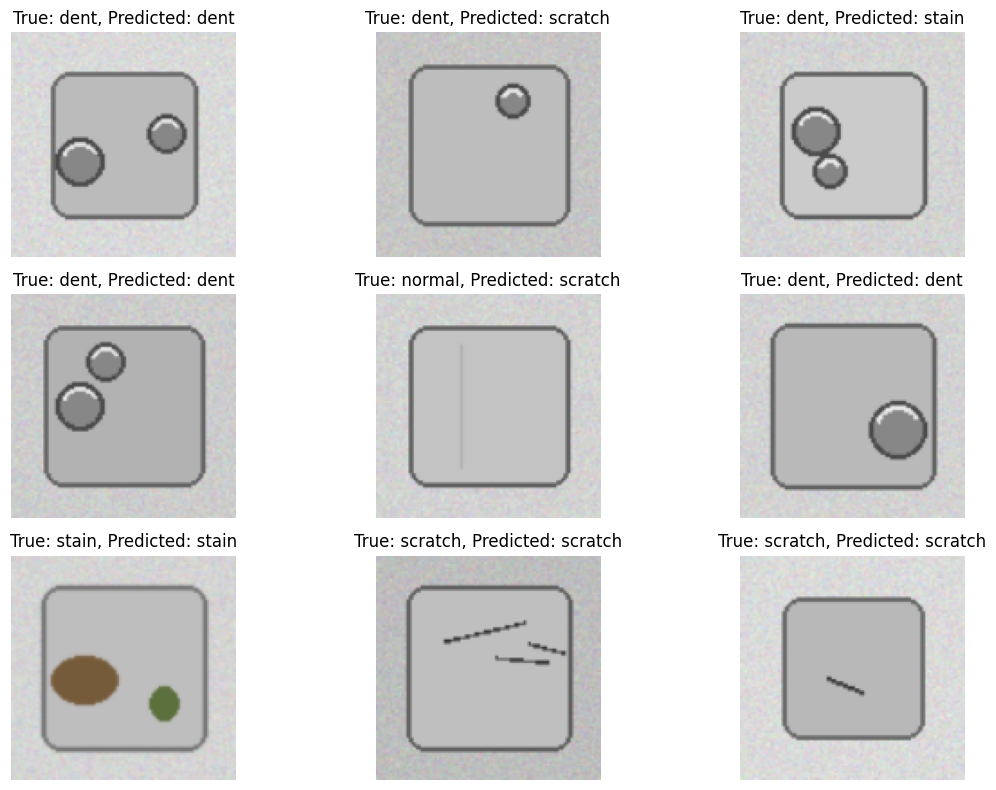

In [ ]:
# Sample predictions on test images

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i])
    plt.title(f'True: {classes[y_test[i]]}, Predicted: {classes[y_pred_classes[i]]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Task 6: CNN Concept Explanation**

What is convolution? Convolution is a mathematical operation used in CNNs where a small filter (kernel) moves across an image to detect important features such as edges, textures, patterns, or shapes.

Why is pooling used? Pooling is used to reduce the size of feature maps generated after convolution. It helps in reduce computation, reduce memory usage, prevent overfitting.

Why is ReLU commonly used in CNNs? It is commonly used because, it introduces non-linearity into the model, it helps CNNs learn complex patterns, it speeds up training and it reduces the vanishing gradient problem.

Why are CNNs better than regular feed-forward networks for image data? CNNs are specifically designed for image processing. Unlike regular feed-forward neural networks, CNNs can automatically detect spatial patterns and important visual features. Regular feed-forward networks treat images as simple flat data, which causes loss of important visual information. CNNs overcome this problem by using convolution and pooling operations.



# **Task 7: Business Use Case Mapping Manufacturing Quality Inspection**

This computer vision can be used in he manufacturing industry for automated quality inspection of products. In manufacturing environments, products may develop defects such as scratches, dents, or stains during production. Manually inspecting every product is time-consuming, expensive, and prone to human error. Using a CNN-based image classification system, cameras can capture images of products on a production line and automatically classify

The system can detect defective products in real time and remove them before packaging or shipping.

Benefits of this solution: • Improves product quality • Reduces human inspection effort • Increases production efficiency